## Import libs

In [2]:
from __future__ import annotations

import time
from copy import deepcopy
from pathlib import Path
from typing import Callable, Tuple
from dataclasses import dataclass, field
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import (
    MobileNet_V2_Weights,
    ResNet18_Weights,
    mobilenet_v2,
    resnet18,
)

# Custom models

## Load dataset and train/val split

In [3]:
DATA_DIR = Path("dataset")
BATCH_SIZE = 32
VAL_RATIO = 0.2
SEED = 42
TORCH_GENERATOR = torch.Generator().manual_seed(SEED)

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_dataset = ImageFolder(root=str(DATA_DIR.resolve()), transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)

train_dataset, val_dataset = random_split(
    full_dataset, [1 - VAL_RATIO, VAL_RATIO],
    generator=TORCH_GENERATOR
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

display(f"Train size: {len(train_dataset)} | Validation size: {len(val_dataset)} | Num of classes: {num_classes}")

'Train size: 106 | Validation size: 26 | Num of classes: 8'

## Device setup

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Custom CNN architectures: Flatten vs GAP

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

class CNNFlatten(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.block1 = ConvBlock(3, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.fc = nn.Linear(128 * 4 * 4, num_classes)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

class CNNGAP(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.block1 = ConvBlock(3, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

## Init models, criterion, otimizers and shedulers

In [6]:
torch.manual_seed(SEED)
model_flat = CNNFlatten(num_classes).to(DEVICE)

torch.manual_seed(SEED)
model_gap = CNNGAP(num_classes).to(DEVICE)

EPOCHS = 10
LR = 1e-3
SCHEDULER_STEP_DIVISOR = 2
SCHEDULER_GAMMA = 0.5

criterion = nn.CrossEntropyLoss()

optimizer_flat = torch.optim.Adam(model_flat.parameters(), lr=LR)
optimizer_gap = torch.optim.Adam(model_gap.parameters(), lr=LR)

scheduler_flat = torch.optim.lr_scheduler.StepLR(
    optimizer_flat, step_size=max(1, EPOCHS // SCHEDULER_STEP_DIVISOR), gamma=SCHEDULER_GAMMA
)
scheduler_gap = torch.optim.lr_scheduler.StepLR(
    optimizer_gap, step_size=max(1, EPOCHS // SCHEDULER_STEP_DIVISOR), gamma=SCHEDULER_GAMMA
)

## Training history tracker

In [7]:
@dataclass
class TrainingHistory:
    train_loss: list[float] = field(default_factory=list)
    val_loss: list[float] = field(default_factory=list)
    train_acc: list[float] = field(default_factory=list)
    val_acc: list[float] = field(default_factory=list)

    def record(self, train_loss: float, train_acc: float, val_loss: float, val_acc: float) -> None:
        self.train_loss.append(train_loss)
        self.val_loss.append(val_loss)
        self.train_acc.append(train_acc)
        self.val_acc.append(val_acc)

    def best_val_acc(self) -> float:
        return max(self.val_acc)

## Best checkpoint saver

In [8]:
class BestCheckpoint:
    def __init__(self) -> None:
        self.best_val: float = 0.0
        self.best_state: dict[str, torch.Tensor] | None = None

    def update(self, val_acc: float, model: nn.Module) -> None:
        if val_acc > self.best_val:
            self.best_val = val_acc
            self.best_state = deepcopy(model.state_dict())

    def restore(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

## Timer

In [9]:
class Timer:
    def __enter__(self) -> "Timer":
        self._start = time.perf_counter()
        return self

    def __exit__(self, *exc_info: object) -> None:
        self.elapsed = time.perf_counter() - self._start

## Train models

In [10]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
) -> Tuple[float, float]:
    model.train()
    total_loss, correct, total = (0, 0, 0)

    for images, labels in loader:
        optimizer.zero_grad(set_to_none=True)

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        pred = outputs.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
) -> Tuple[float, float]:
    model.eval()
    total_loss, correct, total = (0, 0, 0)

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def fit(
    model: nn.Module,
    model_name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    epochs: int,
) -> TrainingHistory:
    display(f"Fitting {model_name}")

    history = TrainingHistory()
    checkpoint = BestCheckpoint()

    with Timer() as timer:
        for epoch in range(epochs):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
            va_loss, va_acc = evaluate_one_epoch(model, val_loader)

            scheduler.step()
            history.record(tr_loss, tr_acc, va_loss, va_acc)
            lr_cur = scheduler.get_last_lr()[0]

            display(f"epoch {epoch + 1}/{epochs} lr={lr_cur:.6f} accuracy={va_acc:.6f}")

            checkpoint.update(va_acc, model)

    checkpoint.restore(model)
    history.elapsed_seconds = timer.elapsed
    return history

torch.manual_seed(SEED)
training_history_flat = fit(model_flat, "CNNFlatten", train_loader, val_loader, optimizer_flat, scheduler_flat, EPOCHS)

torch.manual_seed(SEED)
training_history_gap = fit(model_gap, "CNNGAP", train_loader, val_loader, optimizer_gap, scheduler_gap, EPOCHS)

'Fitting CNNFlatten'

'epoch 1/10 lr=0.001000 accuracy=0.461538'

'epoch 2/10 lr=0.001000 accuracy=0.346154'

'epoch 3/10 lr=0.001000 accuracy=0.653846'

'epoch 4/10 lr=0.001000 accuracy=0.692308'

...

'epoch 6/10 lr=0.000500 accuracy=0.615385'

'epoch 7/10 lr=0.000500 accuracy=0.730769'

'epoch 8/10 lr=0.000500 accuracy=0.730769'

'epoch 9/10 lr=0.000500 accuracy=0.807692'

'epoch 10/10 lr=0.000250 accuracy=0.884615'

# Transfer learning

## Load dataset and train/val split

In [11]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
EPOCHS_TL = 10
LR_FE = 1e-3
LR_FT = 1e-4

tl_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_tl = ImageFolder(root=str(DATA_DIR.resolve()), transform=tl_transform)
train_tl, val_tl = random_split(
    full_tl, [1 - VAL_RATIO, VAL_RATIO],
    generator=TORCH_GENERATOR,
)

train_loader_tl = DataLoader(train_tl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tl = DataLoader(val_tl, batch_size=BATCH_SIZE, shuffle=False)

## Functions for adjust transfer learning models

In [12]:
def freeze_all_except(model: nn.Module, trainable_modules: list[nn.Module]) -> None:
    for p in model.parameters():
        p.requires_grad = False
    for module in trainable_modules:
        for p in module.parameters():
            p.requires_grad = True

def make_resnet(num_classes: int) -> nn.Module:
    m = resnet18(weights=ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


def make_mnv2(num_classes: int) -> nn.Module:
    m = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    in_f = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_f, num_classes)
    return m

## Init models, criterion, otimizers and shedulers

In [13]:
torch.manual_seed(SEED)
model_r18_fe = make_resnet(num_classes).to(DEVICE)

torch.manual_seed(SEED)
model_r18_ft = make_resnet(num_classes).to(DEVICE)

torch.manual_seed(SEED)
model_m2_fe = make_mnv2(num_classes).to(DEVICE)

torch.manual_seed(SEED)
model_m2_ft = make_mnv2(num_classes).to(DEVICE)

freeze_all_except(model_r18_fe, [model_r18_fe.fc])
freeze_all_except(model_r18_ft, [model_r18_ft.layer4, model_r18_ft.fc])
freeze_all_except(model_m2_fe, [model_m2_fe.classifier])
freeze_all_except(model_m2_ft, [model_m2_ft.features[-1], model_m2_ft.classifier])

optimizer_r18_fe = torch.optim.Adam([p for p in model_r18_fe.parameters() if p.requires_grad], lr=LR_FE)
optimizer_r18_ft = torch.optim.Adam([p for p in model_r18_ft.parameters() if p.requires_grad], lr=LR_FT)
optimizer_m2_fe = torch.optim.Adam([p for p in model_m2_fe.parameters() if p.requires_grad], lr=LR_FE)
optimizer_m2_ft = torch.optim.Adam([p for p in model_m2_ft.parameters() if p.requires_grad], lr=LR_FT)

scheduler_r18_fe = torch.optim.lr_scheduler.StepLR(
    optimizer_r18_fe, step_size=max(1, EPOCHS_TL // SCHEDULER_STEP_DIVISOR), gamma=SCHEDULER_GAMMA
)
scheduler_r18_ft = torch.optim.lr_scheduler.StepLR(
    optimizer_r18_ft, step_size=max(1, EPOCHS_TL // SCHEDULER_STEP_DIVISOR), gamma=SCHEDULER_GAMMA
)
scheduler_m2_fe = torch.optim.lr_scheduler.StepLR(
    optimizer_m2_fe, step_size=max(1, EPOCHS_TL // SCHEDULER_STEP_DIVISOR), gamma=SCHEDULER_GAMMA
)
scheduler_m2_ft = torch.optim.lr_scheduler.StepLR(
    optimizer_m2_ft, step_size=max(1, EPOCHS_TL // SCHEDULER_STEP_DIVISOR), gamma=SCHEDULER_GAMMA
)

## Train models

In [14]:
torch.manual_seed(SEED)
hist_r18_fe = fit(model_r18_fe, "ResNet18 FE", train_loader_tl, val_loader_tl, optimizer_r18_fe, scheduler_r18_fe, EPOCHS_TL)

torch.manual_seed(SEED)
hist_r18_ft = fit(model_r18_ft, "ResNet18 FT", train_loader_tl, val_loader_tl, optimizer_r18_ft, scheduler_r18_ft, EPOCHS_TL)

torch.manual_seed(SEED)
hist_m2_fe = fit(model_m2_fe, "MobileNetV2 FE", train_loader_tl, val_loader_tl, optimizer_m2_fe, scheduler_m2_fe, EPOCHS_TL)

torch.manual_seed(SEED)
hist_m2_ft = fit(model_m2_ft, "MobileNetV2 FT", train_loader_tl, val_loader_tl, optimizer_m2_ft, scheduler_m2_ft, EPOCHS_TL)

'Fitting ResNet18 FE'

'epoch 1/10 lr=0.001000 accuracy=0.192308'

'epoch 2/10 lr=0.001000 accuracy=0.307692'

'epoch 3/10 lr=0.001000 accuracy=0.576923'

'epoch 4/10 lr=0.001000 accuracy=0.692308'

...

'epoch 6/10 lr=0.000050 accuracy=0.423077'

'epoch 7/10 lr=0.000050 accuracy=0.500000'

'epoch 8/10 lr=0.000050 accuracy=0.538462'

'epoch 9/10 lr=0.000050 accuracy=0.576923'

'epoch 10/10 lr=0.000025 accuracy=0.653846'

# Evaluate and compare models

## Consolidate CNN and TL results into unified lookups for comparison

In [15]:
all_experiments: dict[str, tuple[dict[str, list[float]], float]] = {
    "CNNFlatten": (training_history_flat, training_history_flat.elapsed_seconds),
    "CNNGAP": (training_history_gap, training_history_gap.elapsed_seconds),
    "ResNet18 FE": (hist_r18_fe, hist_r18_fe.elapsed_seconds),
    "ResNet18 FT": (hist_r18_ft, hist_r18_ft.elapsed_seconds),
    "MobileNetV2 FE": (hist_m2_fe, hist_m2_fe.elapsed_seconds),
    "MobileNetV2 FT": (hist_m2_ft, hist_m2_ft.elapsed_seconds),
}

experiment_order = [
    "CNNFlatten",
    "CNNGAP",
    "ResNet18 FE",
    "ResNet18 FT",
    "MobileNetV2 FE",
    "MobileNetV2 FT",
]

models_and_loaders: dict[str, tuple[nn.Module, DataLoader]] = {
    "CNNFlatten": (model_flat, val_loader),
    "CNNGAP": (model_gap, val_loader),
    "ResNet18 FE": (model_r18_fe, val_loader_tl),
    "ResNet18 FT": (model_r18_ft, val_loader_tl),
    "MobileNetV2 FE": (model_m2_fe, val_loader_tl),
    "MobileNetV2 FT": (model_m2_ft, val_loader_tl),
}

## Function for summarize results

In [16]:
def collect_predictions(
    model: nn.Module, loader: DataLoader, device: torch.device
) -> tuple[list[int], list[int]]:
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(out.argmax(dim=1).cpu().numpy().tolist())
    return y_true, y_pred

def metrics_from_lists(y_true: list[int], y_pred: list[int]) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(
            precision_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "recall_macro": float(
            recall_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "f1_macro": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
    }

def val_metrics(model: nn.Module, loader: DataLoader, device: torch.device) -> dict[str, float]:
    y_true, y_pred = collect_predictions(model, loader, device)
    return metrics_from_lists(y_true, y_pred)

## Summarize results

In [17]:
rows = []
for name in experiment_order:
    hist, sec = all_experiments[name]
    model, loader = models_and_loaders[name]
    vm = val_metrics(model, loader, DEVICE)
    rows.append(
        {
            "Experiment": name,
            "Training time (s)": round(sec, 1),
            "Best val accuracy": round(max(hist.val_acc), 4),
            "Accuracy (val)": round(vm["accuracy"], 4),
            "Precision macro": round(vm["precision_macro"], 4),
            "Recall macro": round(vm["recall_macro"], 4),
            "F1 macro": round(vm["f1_macro"], 4),
            "Best train accuracy": round(max(hist.train_acc), 4),
        }
    )
summary_df = pd.DataFrame(rows)
display(summary_df)

,Experiment,Training time (s),Best val accuracy,Accuracy (val),Precision macro,Recall macro,F1 macro,Best train accuracy
0,CNNFlatten,6.1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,CNNGAP,5.0,0.8846,0.8846,0.9333,0.8812,0.8905,0.9528
2,ResNet18 FE,7.9,0.8462,0.8462,0.8667,0.8083,0.8206,0.9528
3,ResNet18 FT,8.3,0.9231,0.9231,0.9479,0.8958,0.9041,1.0000
4,MobileNetV2 FE,8.1,0.9231,0.9231,0.9375,0.8958,0.8970,0.9623
5,MobileNetV2 FT,8.0,0.6538,0.6538,0.6631,0.6500,0.5887,0.8113


## Plot loss and accuracy curves

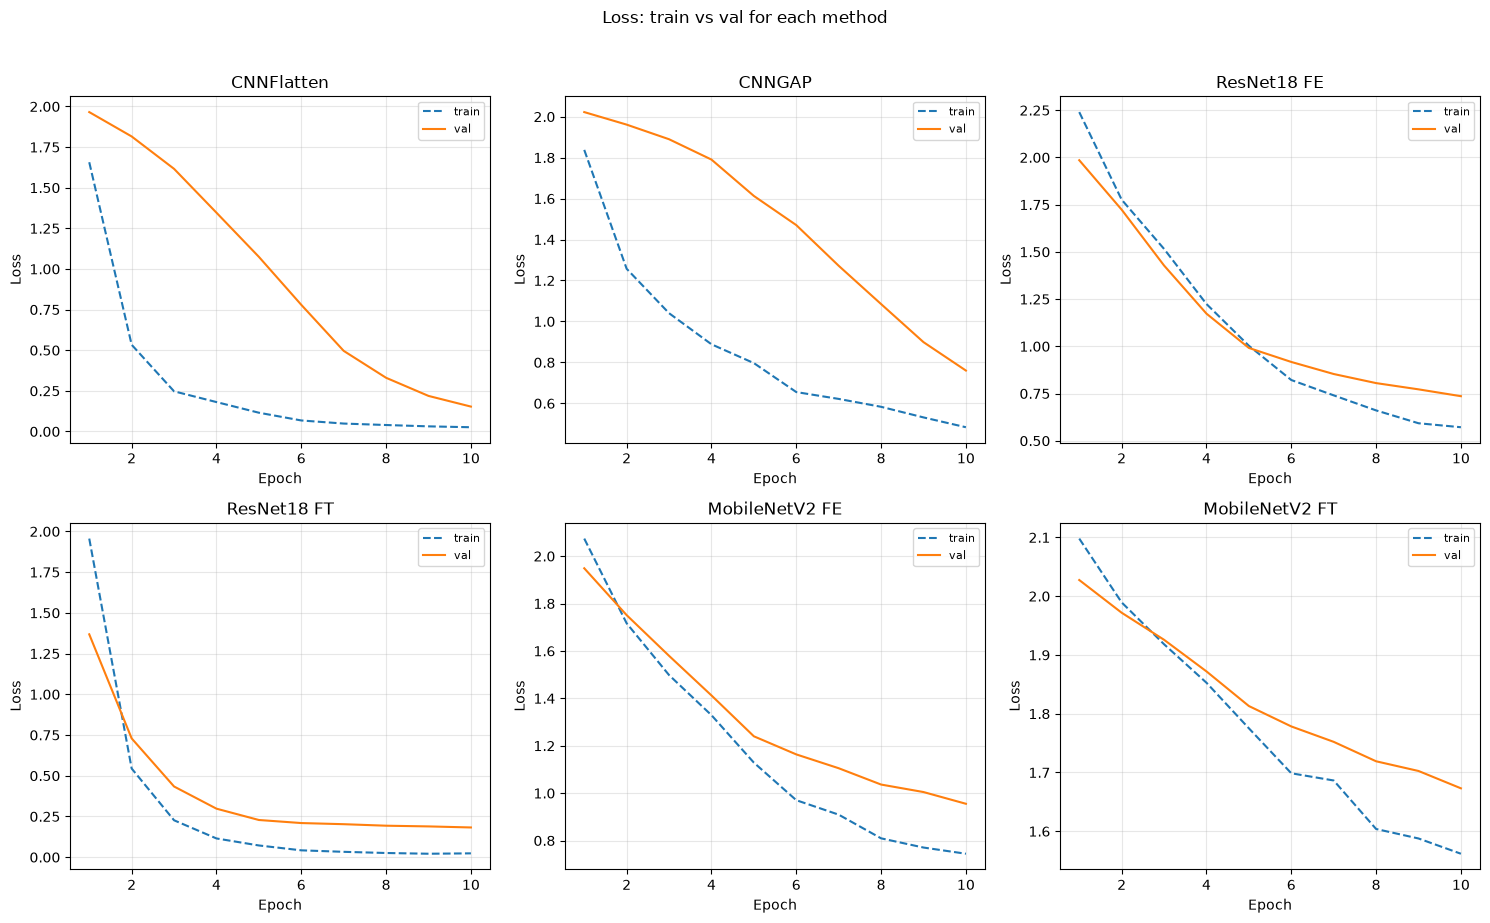

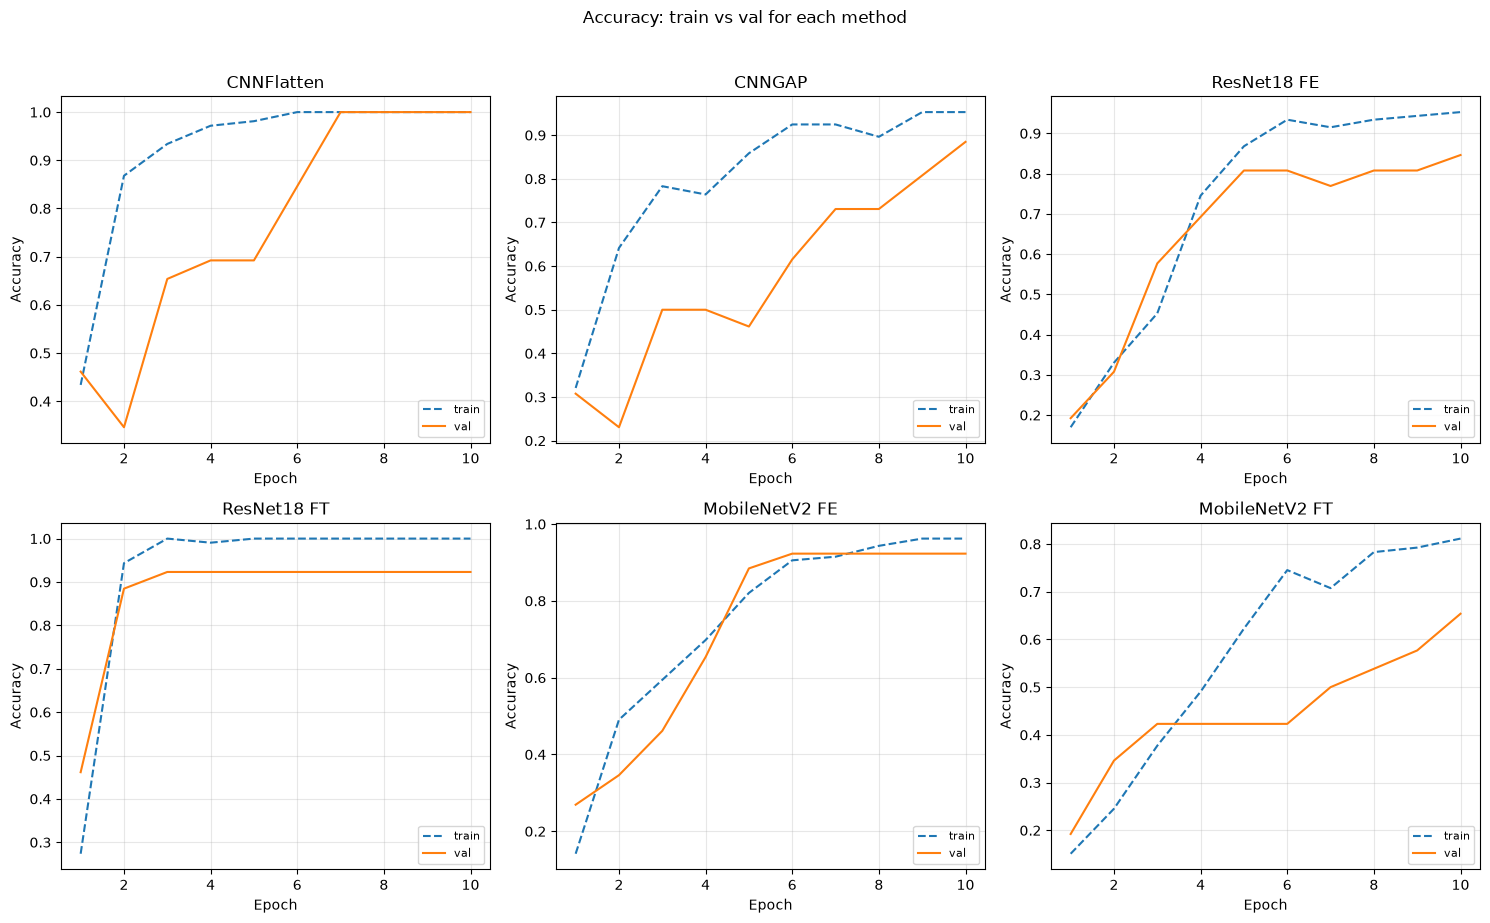

In [18]:
fig_loss, axes_loss = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes_loss.flatten(), experiment_order):
    hist = all_experiments[name][0]
    xs = list(range(1, len(hist.val_loss) + 1))
    ax.plot(xs, hist.train_loss, label="train", linestyle="--")
    ax.plot(xs, hist.val_loss, label="val")
    ax.set(xlabel="Epoch", ylabel="Loss", title=name)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Loss: train vs val for each method", y=1.02)
plt.tight_layout()
plt.show()

fig_acc, axes_acc = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes_acc.flatten(), experiment_order):
    hist = all_experiments[name][0]
    xs = list(range(1, len(hist.val_acc) + 1))
    ax.plot(xs, hist.train_acc, label="train", linestyle="--")
    ax.plot(xs, hist.val_acc, label="val")
    ax.set(xlabel="Epoch", ylabel="Accuracy", title=name)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Accuracy: train vs val for each method", y=1.02)
plt.tight_layout()
plt.show()

## Define best model

In [19]:
candidates: list[tuple[str, nn.Module, DataLoader]] = [
    (name, models_and_loaders[name][0], models_and_loaders[name][1])
    for name in experiment_order
]
best_name, best_model, best_loader = max(
    candidates,
    key=lambda item: val_metrics(item[1], item[2], DEVICE)["f1_macro"],
)
bm = val_metrics(best_model, best_loader, DEVICE)
print(
    "Best model for CM:",
    best_name,
    "accuracy",
    round(bm["accuracy"], 4),
    "precision",
    round(bm["precision_macro"], 4),
    "recall",
    round(bm["recall_macro"], 4),
    "f1",
    round(bm["f1_macro"], 4),
)

Best model for CM: CNNFlatten accuracy 1.0 precision 1.0 recall 1.0 f1 1.0


## Draw confusion matrix

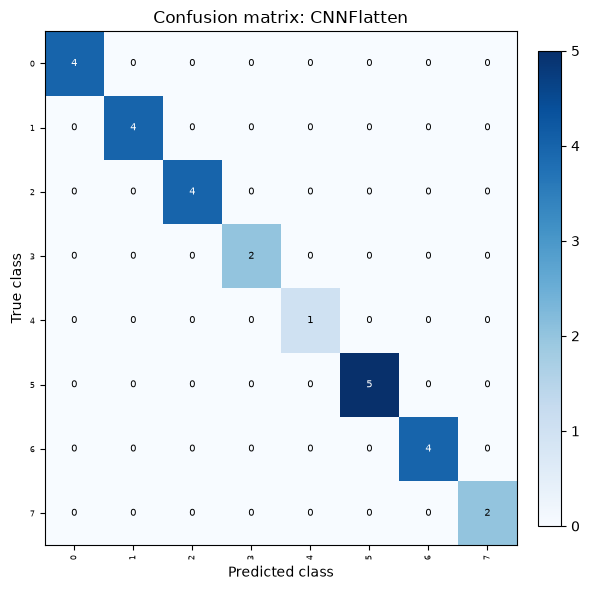

In [20]:
y_true, y_pred = collect_predictions(best_model, best_loader, DEVICE)

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
step = max(1, num_classes // 20)
fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
im = ax_cm.imshow(cm, cmap="Blues", aspect="auto")
fig_cm.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
ax_cm.set(
    xlabel="Predicted class",
    ylabel="True class",
    title=f"Confusion matrix: {best_name}",
    xticks=list(range(0, num_classes, step)),
    yticks=list(range(0, num_classes, step)),
)
ax_cm.tick_params(axis="x", rotation=90, labelsize=6)
ax_cm.tick_params(axis="y", labelsize=6)

CM_ANNOTATION_MAX_CLASSES = 30
if num_classes <= CM_ANNOTATION_MAX_CLASSES:
    threshold = cm.max() / 2
    for i in range(num_classes):
        for j in range(num_classes):
            value = int(cm[i, j])
            color = "white" if value > threshold else "black"
            ax_cm.text(j, i, str(value), ha="center", va="center", color=color, fontsize=7)

fig_cm.tight_layout()
plt.show()

## Saving models

In [21]:
def save_checkpoint(path: Path, model: nn.Module) -> None:
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "num_classes": num_classes,
        },
        path,
    )

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

save_checkpoint(MODELS_DIR / "cnn_flatten.pt", model_flat)
save_checkpoint(MODELS_DIR / "cnn_gap.pt", model_gap)
save_checkpoint(MODELS_DIR / "resnet18_fe.pt", model_r18_fe)
save_checkpoint(MODELS_DIR / "resnet18_ft.pt", model_r18_ft)
save_checkpoint(MODELS_DIR / "mobilenetv2_fe.pt", model_m2_fe)
save_checkpoint(MODELS_DIR / "mobilenetv2_ft.pt", model_m2_ft)

## Visualize sample predictions

Val 32×32 (CNN):


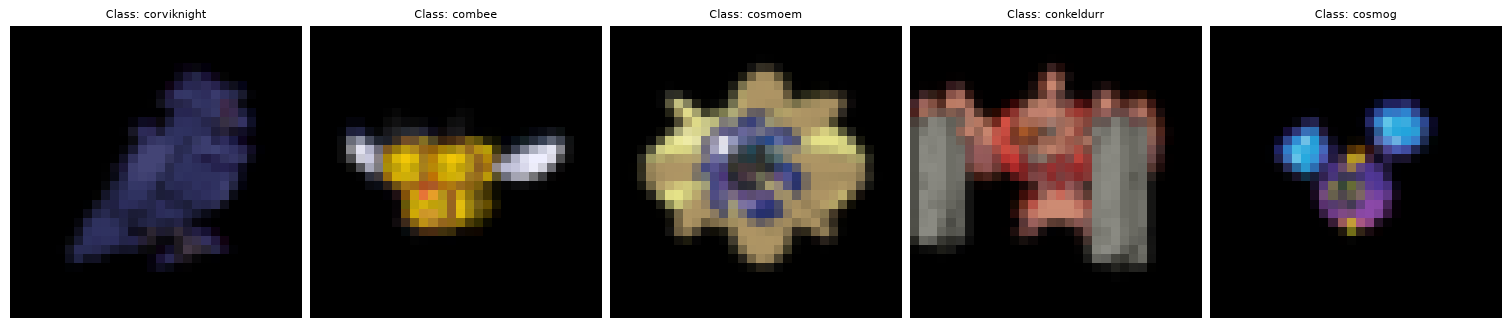

Val 224×224 (ImageNet, TL):


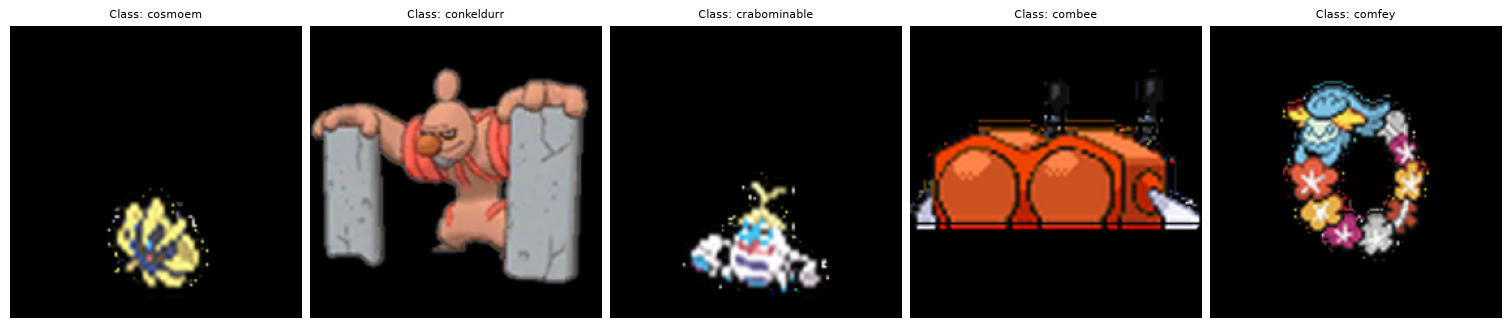

Best model predictions: CNNFlatten


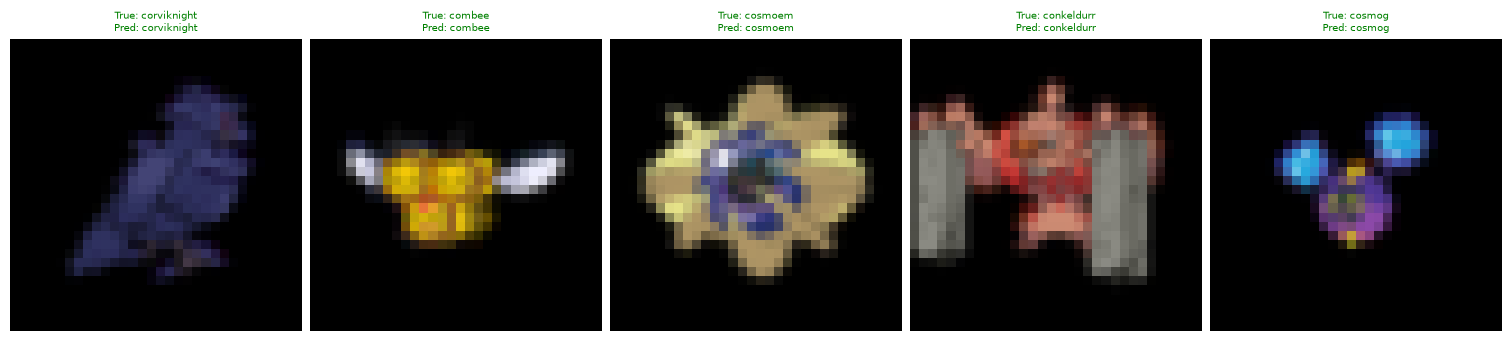

In [22]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225])

def _to_hwc(img_chw: torch.Tensor, denorm_imagenet: bool) -> torch.Tensor:
    img = img_chw.permute(1, 2, 0)
    if denorm_imagenet:
        img = torch.clamp(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)
    else:
        img = torch.clamp(img * 0.5 + 0.5, 0, 1)
    return img

def visualize_batch(
    dataloader: DataLoader,
    class_names: list[str],
    num_images: int = 5,
    denorm_imagenet: bool = False,
    model: nn.Module | None = None,
) -> None:
    images, labels = next(iter(dataloader))
    predicted = None
    if model is not None:
        model.eval()
        with torch.no_grad():
            predicted = model(images.to(DEVICE)).argmax(dim=1).cpu()

    n = min(num_images, images.size(0))
    w = min(3 * n, 18)
    fig, axes = plt.subplots(1, n, figsize=(w, 6), constrained_layout=True, squeeze=False)
    for i in range(n):
        ax = axes[0, i]
        img = _to_hwc(images[i].cpu(), denorm_imagenet)
        ax.imshow(img, vmin=0, vmax=1)
        true_label = class_names[int(labels[i].item())]
        if predicted is not None:
            pred_label = class_names[int(predicted[i])]
            color = "green" if pred_label == true_label else "red"
            ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=7)
        else:
            ax.set_title(f"Class: {true_label}", fontsize=8)
        ax.axis("off")
    plt.show()


print("Val 32×32 (CNN):")
visualize_batch(val_loader, class_names, num_images=5, denorm_imagenet=False)
print("Val 224×224 (ImageNet, TL):")
visualize_batch(val_loader_tl, class_names, num_images=5, denorm_imagenet=True)
print("Best model predictions:", best_name)
_, loader_best = models_and_loaders[best_name]
visualize_batch(
    loader_best,
    class_names,
    num_images=5,
    denorm_imagenet=best_name not in ("CNNFlatten", "CNNGAP"),
    model=best_model,
)

## Summary statistics: best model per metric

| Experiment | Training time (s) | Best val accuracy | Accuracy (val) | Precision macro | Recall macro | F1 macro | Best train accuracy |
| --- | --- | --- | --- | --- | --- | --- | --- |
| CNNFlatten | 6.1 | <u>**1.0**</u> | <u>**1.0**</u> | <u>**1.0**</u> | <u>**1.0**</u> | <u>**1.0**</u> | <u>**1.0**</u> |
| CNNGAP | <u>**5.0**</u> | 0.8846 | 0.8846 | 0.9333 | 0.8812 | 0.8905 | 0.9528 |
| ResNet18 FE | 7.9 | 0.8462 | 0.8462 | 0.8667 | 0.8083 | 0.8206 | 0.9528 |
| ResNet18 FT | 8.3 | 0.9231 | 0.9231 | 0.9479 | 0.8958 | 0.9041 | 1.0 |
| MobileNetV2 FE | 8.1 | 0.9231 | 0.9231 | 0.9375 | 0.8958 | 0.897 | 0.9623 |
| MobileNetV2 FT | 8.0 | 0.6538 | 0.6538 | 0.6631 | 0.65 | 0.5887 | 0.8113 |